In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
df = pd.read_csv("C:/Users/Dell/Downloads/ecommerce_dataset.csv")

In [8]:
df.head()

,Order_ID,Customer_ID,Age,Gender,City,Category,Product,Price,Quantity,Discount,Profit,Order_Date,Payment_Method,Order_Status,Shipping_Days
0,100000,1235,43,Male,Bangalore,Sports,Cricket Bat,8869,2,0.09,1182.46,2024-05-21,Credit Card,Returned,6
1,100001,13172,45,Female,Hyderabad,Books,Self Help,233,1,0.12,14.97,2022-01-29,UPI,Delivered,5
2,100002,6192,64,Male,Kolkata,Grocery,Rice,587,3,0.23,391.08,2022-02-12,Cash on Delivery,Delivered,9
3,100003,18289,48,Female,Ahmedabad,Books,Biography,1389,4,0.27,1121.59,2023-02-04,Credit Card,Delivered,7
4,100004,11955,41,Female,Patna,Books,Novel,919,5,0.21,902.60,2022-10-19,Net Banking,Cancelled,7


In [13]:
df.tail()

,Order_ID,Customer_ID,Age,Gender,City,Category,Product,Price,Quantity,Discount,Profit,Order_Date,Payment_Method,Order_Status,Shipping_Days
49995,149995,1802,19,Male,Lucknow,Sports,Yoga Mat,731,5,0.31,623.42,2023-07-27,UPI,Delivered,1
49996,149996,11221,48,Female,Chennai,Sports,Yoga Mat,11882,1,0.34,2888.23,2022-10-15,UPI,Cancelled,1
49997,149997,13237,45,Male,Lucknow,Grocery,Oil,1088,5,0.16,669.96,2024-01-17,Credit Card,Delivered,7
49998,149998,1508,30,Male,Lucknow,Sports,Yoga Mat,2241,3,0.33,1160.94,2022-01-07,UPI,Shipped,3
49999,149999,11836,20,Male,Chennai,Home Decor,Wall Art,5268,3,0.01,1805.44,2022-04-21,Cash on Delivery,Shipped,4


In [14]:
df.shape

(50000, 15)

In [15]:
df.columns

Index(['Order_ID', 'Customer_ID', 'Age', 'Gender', 'City', 'Category',
       'Product', 'Price', 'Quantity', 'Discount', 'Profit', 'Order_Date',
       'Payment_Method', 'Order_Status', 'Shipping_Days'],
      dtype='object')

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order_ID        50000 non-null  int64  
 1   Customer_ID     50000 non-null  int64  
 2   Age             50000 non-null  int64  
 3   Gender          50000 non-null  object 
 4   City            50000 non-null  object 
 5   Category        50000 non-null  object 
 6   Product         50000 non-null  object 
 7   Price           50000 non-null  int64  
 8   Quantity        50000 non-null  int64  
 9   Discount        50000 non-null  float64
 10  Profit          50000 non-null  float64
 11  Order_Date      50000 non-null  object 
 12  Payment_Method  50000 non-null  object 
 13  Order_Status    50000 non-null  object 
 14  Shipping_Days   50000 non-null  int64  
dtypes: float64(2), int64(6), object(7)
memory usage: 5.7+ MB


In [20]:
#  QUES1) Find the total revenue 
df["Revenue"] = df["Price"] * df["Quantity"]
df["Revenue"].sum()
                

1308327416

In [21]:
# QUES2) Top 10 cities by sale
City_sales = df.groupby("City")["Revenue"].sum()
City_sales.sort_values(ascending= False).head(10)



City
Mumbai       134989377
Ahmedabad    134135658
Lucknow      133959099
Chennai      133271102
Delhi        131883223
Kolkata      129821263
Bangalore    129033571
Patna        127949074
Pune         127674330
Hyderabad    125610719
Name: Revenue, dtype: int64

In [24]:
# QUES3)  
Most Sold product category
category_sale = df.groupby("Category")["Quantity"].sum()
category_sale.sort_values(ascending = False)

Category
Clothing       21804
Home Decor     21687
Sports         21681
Electronics    21491
Beauty         21361
Grocery        21313
Books          21302
Name: Quantity, dtype: int64

In [26]:
df["Payment_Method"].value_counts()

Payment_Method
Net Banking         10088
Debit Card          10086
Credit Card          9983
UPI                  9979
Cash on Delivery     9864
Name: count, dtype: int64

C:\Users\Dell\AppData\Local\Temp\ipykernel_26540\1398395421.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = "Payment_Method",data = df,palette = "Set3")


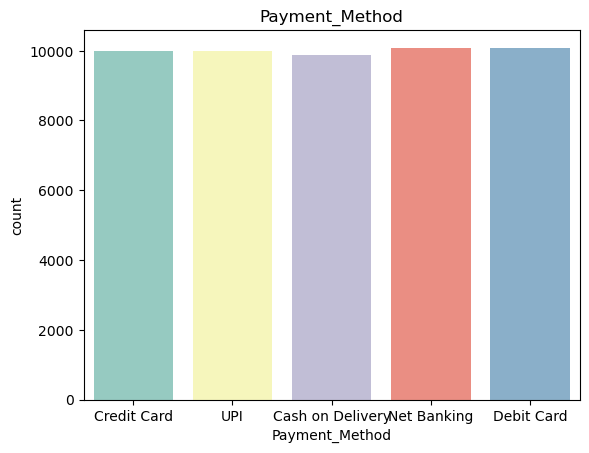

In [3]:
# QUES4) Find the total sale by payment method
import seaborn as sns
sns.countplot(x = "Payment_Method",data = df,palette = "Set3")
plt.title ("Payment_Method")
plt.show()

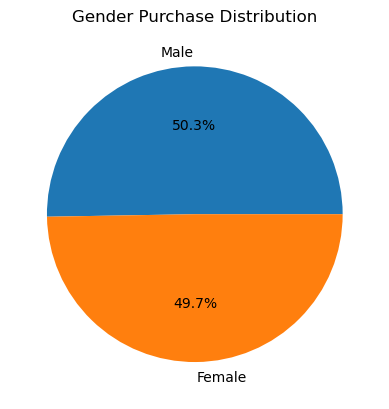

In [5]:
# QUES5) Find the purchase distribution visualize it by creating pie chart.

df["Gender"].value_counts().plot(kind="pie", autopct="%1.1f%%")  
plt.title("Gender Purchase Distribution")
plt.ylabel("")
plt.show()

# ( we use autopct for show percentage in visual )

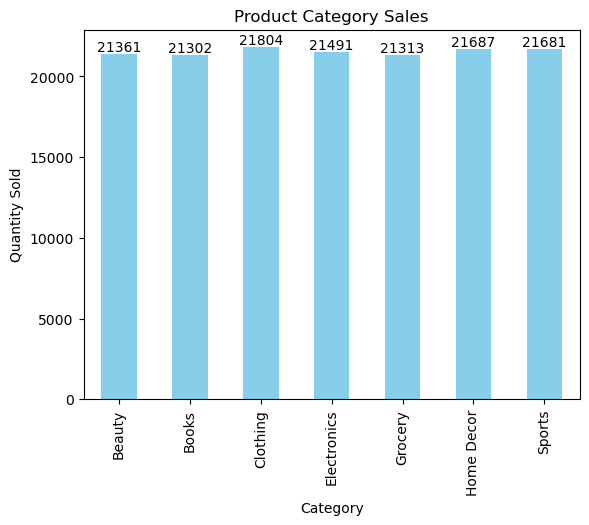

In [15]:
# QUES6) Find the total sales by category and visualize by creating bar chart.

category_sales = df.groupby("Category")["Quantity"].sum()

ax = category_sales.plot(kind="bar", color="skyblue")

for i in ax.containers:
    ax.bar_label(i)

plt.title("Product Category Sales")
plt.xlabel("Category")
plt.ylabel("Quantity Sold")
plt.show()

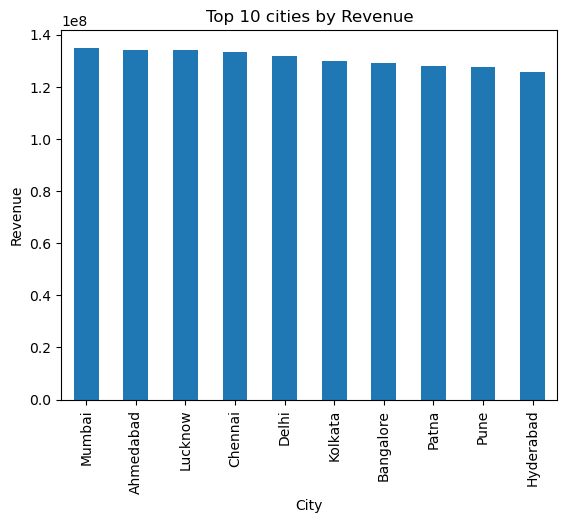

In [24]:
# Ques7) Find the total sales by city by creating bar chart.

city_sales = df.groupby("City")["Revenue"].sum().sort_values(ascending=False).head(10)
city_sales.plot(kind="bar")
plt.title("Top 10 cities by Revenue")
plt.xlabel("City")
plt.ylabel("Revenue")
plt.show()

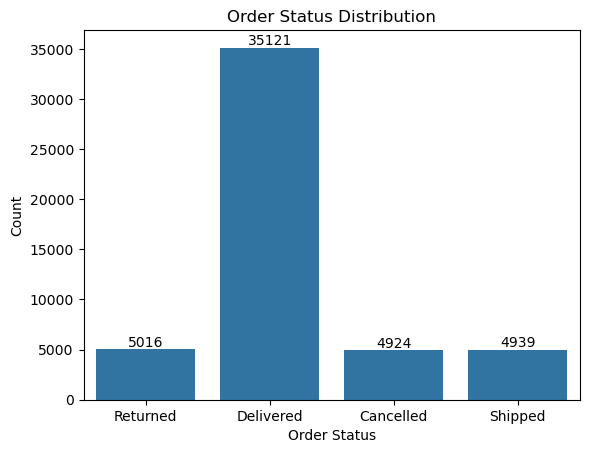

In [30]:
# Ques8) Show the order status analysis 

ax = sns.countplot(x="Order_Status", data=df)

for i in ax.containers:
    ax.bar_label(i)

plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Count")
plt.show()

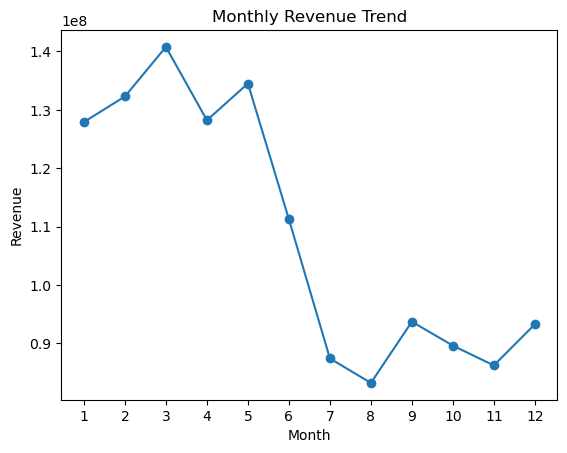

In [39]:
# Ques9) Find the monthly revenue trend analysis.

df["Order_Date"] = pd.to_datetime(df["Order_Date"])

monthly_sales = df.groupby(df["Order_Date"].dt.month)["Revenue"].sum()

monthly_sales.plot(kind="line", marker="o")

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(range(1,13))   # 1 se 12 tak sab months show honge

plt.show()

In [48]:
# Ques10) Find the top 10 customers by spending.

top_customers = df.groupby("Customer_ID")["Revenue"].sum()
top_customers.sort_values(ascending=False).head(10)                            
                            
                            

Customer_ID
3835     900299
8744     867470
13237    866873
1190     843761
8516     763056
7971     698513
14944    694784
16068    692098
2511     691921
11036    688556
Name: Revenue, dtype: int64